First few rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


C:\Users\Giris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


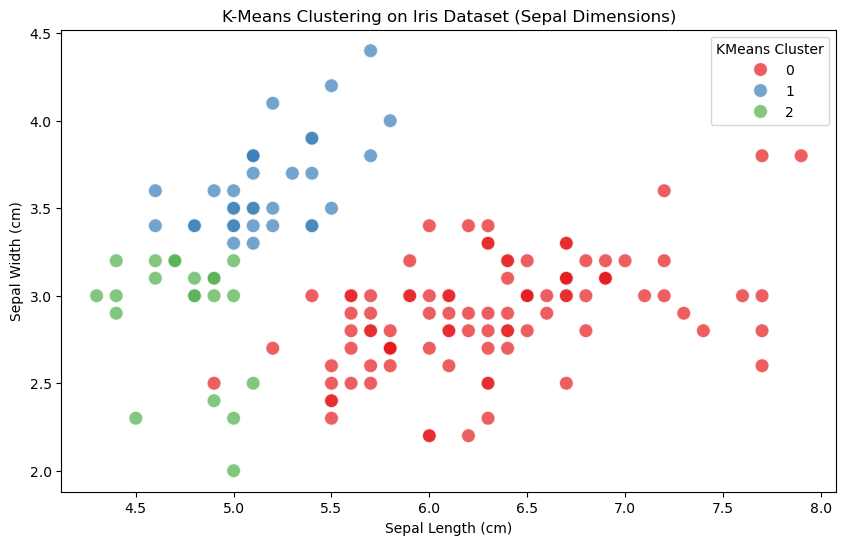


Insight from K-Means Clustering:
K-Means clustering has grouped the data into 3 clusters. These clusters seem to correspond to different species of Iris flowers.
The clusters are formed by minimizing the within-cluster variance, and the algorithm assigns each data point to the closest centroid.



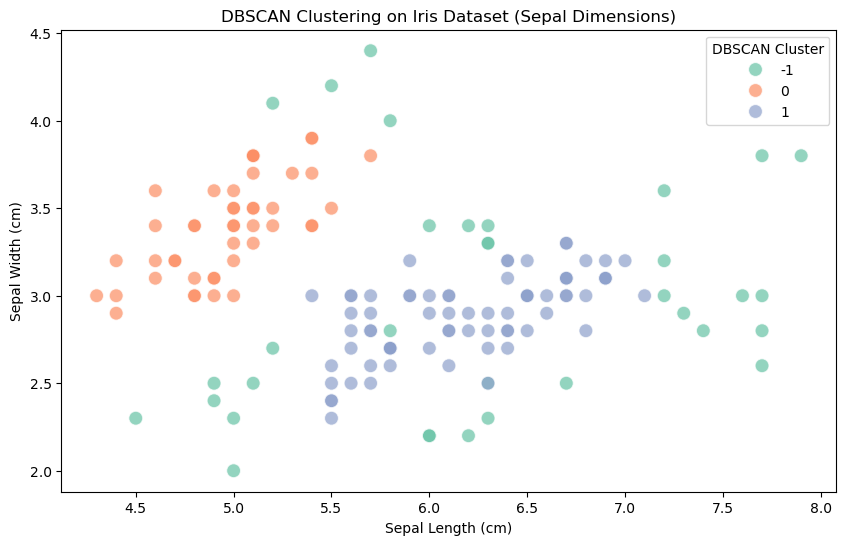


Insight from DBSCAN Clustering:
DBSCAN has grouped the data into 3 clusters, similar to K-Means, but it has also marked some points as noise (labeled -1).
DBSCAN does not require specifying the number of clusters upfront and can handle arbitrarily shaped clusters.



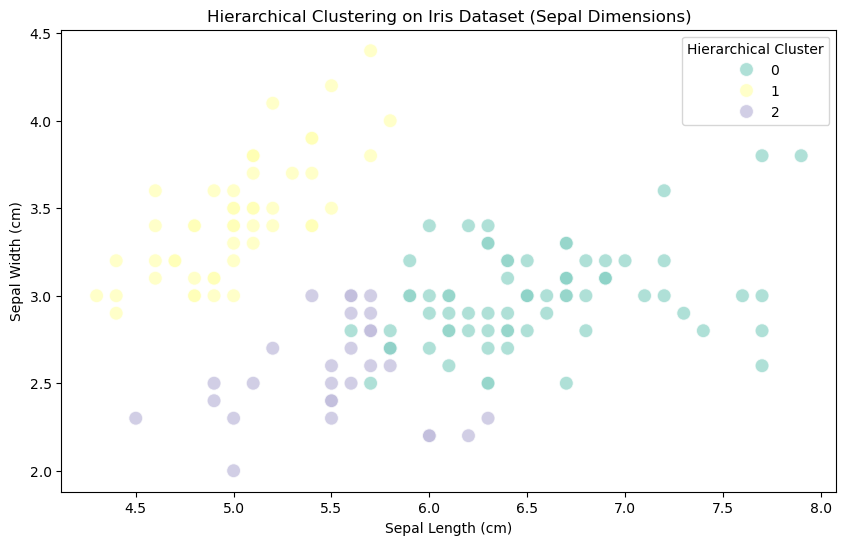


Insight from Hierarchical Clustering:
Hierarchical clustering has grouped the data into 3 clusters by building a tree-like structure (dendrogram).
This method does not require specifying the number of clusters, but we have set it to 3 here. The clusters appear to match well with the Iris species.

K-Means Clustering Distribution:
KMeans Cluster
0    96
1    33
2    21
Name: count, dtype: int64

DBSCAN Clustering Distribution:
DBSCAN Cluster
 1    71
 0    45
-1    34
Name: count, dtype: int64

Hierarchical Clustering Distribution:
Hierarchical Cluster
0    71
1    49
2    30
Name: count, dtype: int64

Conclusion:
K-Means, DBSCAN, and Hierarchical clustering all successfully identified 3 clusters, but DBSCAN was able to detect noise points (-1).
K-Means works well for spherical clusters but assumes a predefined number of clusters. DBSCAN does not require specifying the number of clusters and can detect noise, while Hierarchical clustering provides a dendrogram, which is useful for unde

In [2]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Labels (species)

# Convert to a DataFrame for better readability
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['Species'] = iris.target_names[y]

# Display the first few rows of the dataset
print("First few rows of the Iris dataset:")
print(iris_df.head())

# Step 1: K-Means Clustering
# Standardize the features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means Clustering (set number of clusters to 3 for 3 species)
kmeans = KMeans(n_clusters=3, random_state=42)
iris_df['KMeans Cluster'] = kmeans.fit_predict(X_scaled)

# Visualizing the K-Means clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=iris_df['sepal length (cm)'], y=iris_df['sepal width (cm)'], 
                hue=iris_df['KMeans Cluster'], palette='Set1', s=100, alpha=0.7)
plt.title("K-Means Clustering on Iris Dataset (Sepal Dimensions)")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

# Print insights for K-Means Clustering
print("\nInsight from K-Means Clustering:")
print("K-Means clustering has grouped the data into 3 clusters. These clusters seem to correspond to different species of Iris flowers.")
print("The clusters are formed by minimizing the within-cluster variance, and the algorithm assigns each data point to the closest centroid.\n")

# Step 2: DBSCAN Clustering
# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
iris_df['DBSCAN Cluster'] = dbscan.fit_predict(X_scaled)

# Visualizing the DBSCAN clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=iris_df['sepal length (cm)'], y=iris_df['sepal width (cm)'], 
                hue=iris_df['DBSCAN Cluster'], palette='Set2', s=100, alpha=0.7)
plt.title("DBSCAN Clustering on Iris Dataset (Sepal Dimensions)")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

# Print insights for DBSCAN Clustering
print("\nInsight from DBSCAN Clustering:")
print("DBSCAN has grouped the data into 3 clusters, similar to K-Means, but it has also marked some points as noise (labeled -1).")
print("DBSCAN does not require specifying the number of clusters upfront and can handle arbitrarily shaped clusters.\n")

# Step 3: Hierarchical Clustering
# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
iris_df['Hierarchical Cluster'] = hierarchical.fit_predict(X_scaled)

# Visualizing the Hierarchical Clustering clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=iris_df['sepal length (cm)'], y=iris_df['sepal width (cm)'], 
                hue=iris_df['Hierarchical Cluster'], palette='Set3', s=100, alpha=0.7)
plt.title("Hierarchical Clustering on Iris Dataset (Sepal Dimensions)")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

# Print insights for Hierarchical Clustering
print("\nInsight from Hierarchical Clustering:")
print("Hierarchical clustering has grouped the data into 3 clusters by building a tree-like structure (dendrogram).")
print("This method does not require specifying the number of clusters, but we have set it to 3 here. The clusters appear to match well with the Iris species.\n")

# Step 4: Compare the Results
# Print the cluster counts for each method
print("K-Means Clustering Distribution:")
print(iris_df['KMeans Cluster'].value_counts())
print("\nDBSCAN Clustering Distribution:")
print(iris_df['DBSCAN Cluster'].value_counts())
print("\nHierarchical Clustering Distribution:")
print(iris_df['Hierarchical Cluster'].value_counts())

# Conclusion
print("\nConclusion:")
print("K-Means, DBSCAN, and Hierarchical clustering all successfully identified 3 clusters, but DBSCAN was able to detect noise points (-1).")
print("K-Means works well for spherical clusters but assumes a predefined number of clusters. DBSCAN does not require specifying the number of clusters and can detect noise, while Hierarchical clustering provides a dendrogram, which is useful for understanding cluster hierarchies.")
